In [1]:
import numpy as np
from scipy.stats import norm

from common import result ,bsm_put

In [2]:
# Params
S0 = np.array([1.0, 1.5, 1.3])
sigmas = np.array([0.15, 0.2, 0.25])
T_minus_t = 2.0
r = 0.02
K = 3.0


# Matrice de Cholesky L
L = np.array([
    [1.0, 0.0, 0.0],
    [0.25, 0.97, 0.0],
    [0.25, 0.19, 0.95]
])

In [3]:
def asian_basket_put(
    S0: np.ndarray,
    sigmas: np.ndarray,
    L: np.ndarray,
    r: float,
    K: float,
    T_minus_t: float,
    discount: float,
    m: int,
    N: int,
    clip: float = 1e-10,
) -> np.ndarray:
    S0 = np.asarray(S0, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    L = np.asarray(L, dtype=float)

    d = S0.size
    dt = T_minus_t / N

    drift = (r - 0.5 * sigmas**2) * dt
    vol = sigmas * np.sqrt(dt)

    rdm_raw = np.random.random((m, d * N))
    Z = norm.ppf(np.clip(rdm_raw, clip, 1 - clip))
    Z = Z.reshape(m, N, d)

    #Brownian increments (corrélés)
    dW = Z @ L.T
    dW *= vol

    #Log dynamics
    log_increments = drift + dW
    log_paths = np.cumsum(log_increments, axis=1)

    #Asset paths
    S_paths = S0 * np.exp(log_paths)

    #ime integral
    integral_sum = np.sum(S_paths, axis=1) * dt

    #Weighted average
    weighted_avg = np.sum(integral_sum / (S0 * T_minus_t), axis=1)

    #Payoff
    payoffs = np.maximum(K - weighted_avg, 0.0)

    actualized_payoffs = discount * payoffs

    return actualized_payoffs.reshape(m,1)

def asian_basket_put_control_variate(
    S0: np.ndarray,
    sigmas: np.ndarray,
    L: np.ndarray,
    r: float,
    K: float,
    T_minus_t: float,
    m: int,
    N: int,
    clip: float = 1e-10,
) -> tuple[np.ndarray, np.ndarray]:
    S0 = np.asarray(S0, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    L = np.asarray(L, dtype=float)

    d = S0.size
    dt = T_minus_t / N
    discount = np.exp(-r * T_minus_t)

    drift = (r - 0.5 * sigmas**2) * dt
    vol = sigmas * np.sqrt(dt)

    # Génération normales
    u_points = np.random.random((m, d * N))
    Z = norm.ppf(np.clip(u_points, clip, 1 - clip))
    Z = Z.reshape(m, N, d)

    # incréments browniens corrélés
    Z_corr = Z @ L.T

    # Simulation des trajectoires
    log_increments = drift + vol * Z_corr
    log_paths = np.cumsum(log_increments, axis=1)

    S_paths = S0 * np.exp(log_paths)

    # Payoff asiatique panier
    integrals = np.sum(S_paths, axis=1) * dt
    basket_avg = np.sum(integrals / (S0 * T_minus_t), axis=1)

    payoff_raw = np.maximum(K - basket_avg, 0.0) * discount

    # Variables de contrôle
    # puts européens individuels
    terminal_values = S_paths[:, -1, :]

    put_sim = np.maximum(S0 - terminal_values, 0.0) * discount

    put_exact = np.array([
        bsm_put(S0[i], S0[i],r, sigmas[i], T_minus_t)
        for i in range(d)
    ])

    # Estimation des betas
    cov = np.cov(payoff_raw, put_sim, rowvar=False)

    cov_xy = cov[0, 1:]
    var_y = np.diag(cov[1:, 1:])

    betas = cov_xy / var_y

    # Payoff avec réduction de variance
    payoff_reduced = payoff_raw - np.sum(
        betas * (put_sim - put_exact),
        axis=1
    )

    return payoff_reduced.reshape(m,1), betas

In [4]:
m = 10000  # Nombre de points
N = 50     # Pas de temps
discount=np.exp(-r*T_minus_t)

# 3.1 Pricing

In [5]:
actualized_payoffs=asian_basket_put(
    S0,
    sigmas,
    L,
    r,
    K,
    T_minus_t,
    discount,
    m,
    N,
)

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.10744601421878597
std: 0.16375787344833173
------------------------------


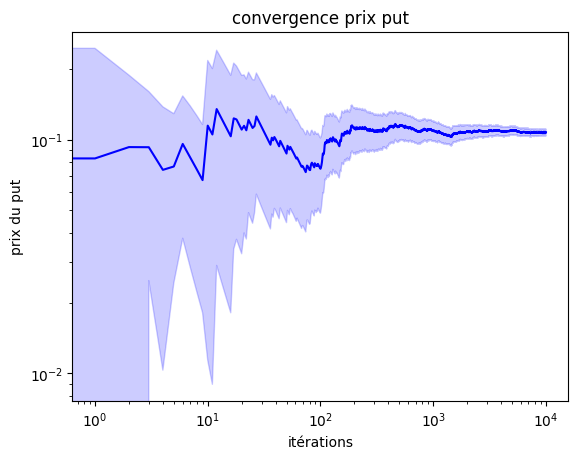

In [6]:
result([actualized_payoffs],y_title="prix du put",global_title="convergence prix put")

# 3.2 Réduction de variance

In [7]:
payoffs_cv, betas = asian_basket_put_control_variate(
    S0=S0,
    sigmas=sigmas,
    L=L,
    r=r,
    K=K,
    T_minus_t=T_minus_t,
    m=m,
    N=N
)

print("Betas :", betas)

Betas : [0.79523079 0.44870575 0.48502648]


------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.10744601421878597
std: 0.16375787344833173
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.11047468843356656
std: 0.11580547316472654
------------------------------


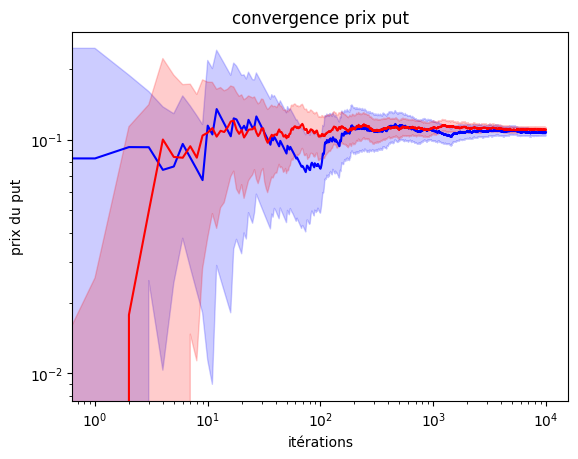

In [8]:
result([actualized_payoffs, payoffs_cv],y_title="prix du put",global_title="convergence prix put")